# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pretom26/ml_internship_flyrankAI/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

Week 6 answered the validation question. Week 7 turns that validated output into something a content team could actually use: a ranked **manual-review queue** with understandable actions, reason codes, guardrails, and lightweight monitoring.

I keep the same Logistic Regression specification from Week 5/6. The client-grouped holdout remains the evidence for model quality; after reproducing that check, I refit the already-validated specification on the full starter dataset only to create the research playbook queue.

The queue is **decision-support, not an automation system**. A high score means “review this page earlier,” not “edit, merge, redirect, or delete it automatically.”

> Skill focus: `writing-honest-claims` + `flyrank/flyrank-data`.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

I separate the **model score** from the **editorial priority score**:

- `model_risk_score` = the Logistic Regression score for the observed decline proxy.
- `demand_percentile` = how much search visibility the page currently carries relative to other eligible pages.
- `review_priority_score` = **75% model risk + 25% demand percentile**, scaled to 0–100.

The 75/25 blend is a transparent editorial policy choice, not a learned coefficient and not something tuned on the Week-6 test set. It prevents a very high model score on a barely visible page from automatically outranking every high-impact page.

I keep the original project eligibility rule of **at least 100 impressions in the trailing 90 days** for the action queue. Pages below that level are not treated as useless; they simply do not have enough search demand for this particular “what should we review first?” queue.

### Archetype → action map

| Archetype | Human action |
|---|---|
| High-impact decay risk | Refresh / update review |
| Thin visible risk | Rewrite / expand review |
| Search snippet opportunity | CTR / metadata review |
| High-value lower-risk | Protect / monitor |
| Emerging review risk | Manual review |
| General watchlist | Monitor |

The action is intentionally phrased as a **review**, not an automatic edit.

Reason codes explain why a page reached the queue, for example: `HIGH_MODEL_RISK`, `HIGH_SEARCH_DEMAND`, `STALE_180D_PLUS`, `LOW_CTR_FOR_POSITION`, `THIN_VISIBLE_PAGE`, and `PAGE_ONE_STALE`.

### Decay / refresh insight

I also re-measure the observed decline rate across staleness bands. This is descriptive only: if older pages show more decline in this snapshot, that supports **reviewing freshness as a signal**. It does **not** show that age causes decline or that updating a page will recover performance.

In [1]:
# ---------- Colab setup + validated model -> ranked action queue ----------

import os
import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
TOP_K = 50
MIN_IMPRESSIONS = 100
RISK_WEIGHT = 0.75
DEMAND_WEIGHT = 0.25

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/pretom26/ml_internship_flyrankAI.git"
REPO_DIR = Path("/content/ml_internship_flyrankAI")

if IN_COLAB:
    if not REPO_DIR.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)],
            check=True
        )
    os.chdir(REPO_DIR)
else:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data/raw/content_refresh_anonymized.csv").exists():
            os.chdir(candidate)
            break

DATA_PATH = Path("data/raw/content_refresh_anonymized.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Missing {DATA_PATH}. Run this notebook from the repo or let the Colab setup clone it."
    )

df = pd.read_csv(DATA_PATH)

# Same observed proxy label used in Week 5/6.
df["is_declining_label"] = (
    df["trend_direction"].astype(str).str.lower().eq("down").astype(np.int8)
)

# FlyRank data rule: avg_position == 0 means "no data", not position zero.
df["avg_position_no_data"] = (
    pd.to_numeric(df["avg_position"], errors="coerce").fillna(0).eq(0)
).astype(np.int8)

df["avg_position_model"] = pd.to_numeric(
    df["avg_position"], errors="coerce"
).replace(0, np.nan)

numeric_to_clean = [
    "days_since_last_update",
    "impressions_90d",
    "ctr",
    "avg_position",
    "word_count",
    "content_age_days",
]
for col in numeric_to_clean:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

FEATURES_NUMERIC = [
    "days_since_last_update",
    "impressions_90d",
    "ctr",
    "avg_position_model",
    "avg_position_no_data",
]
FEATURES_CATEGORICAL = ["content_type"]
FINAL_FEATURES = FEATURES_NUMERIC + FEATURES_CATEGORICAL
TARGET = "is_declining_label"

FORBIDDEN = {
    "is_declining_label",
    "trend_direction",
    "trend_pct",
    "content_id",
    "client_id",
}
assert not (set(FINAL_FEATURES) & FORBIDDEN), "Forbidden/leaky feature found."

def make_model():
    numeric_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])

    categorical_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocess = ColumnTransformer([
        ("num", numeric_pipe, FEATURES_NUMERIC),
        ("cat", categorical_pipe, FEATURES_CATEGORICAL),
    ])

    return Pipeline([
        ("preprocess", preprocess),
        ("logreg", LogisticRegression(max_iter=1000, random_state=SEED)),
    ])

def precision_at_k(y_true, scores, k):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    k = min(k, len(y_true))
    order = np.argsort(-scores, kind="mergesort")[:k]
    return float(y_true[order].mean())

# Reproduce the Week-6 honest split. These are the validation receipts.
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, test_idx = next(
    gss.split(df, y=df[TARGET], groups=df["client_id"])
)

train_part = df.iloc[train_idx].copy()
test_part = df.iloc[test_idx].copy()

validated_model = make_model()
validated_model.fit(train_part[FINAL_FEATURES], train_part[TARGET])

y_test = test_part[TARGET].to_numpy()
test_scores = validated_model.predict_proba(test_part[FINAL_FEATURES])[:, 1]

train_clients = set(train_part["client_id"].astype(str))
test_clients = set(test_part["client_id"].astype(str))
client_overlap = len(train_clients & test_clients)

validated_base_rate = float(y_test.mean())
validated_p50 = precision_at_k(y_test, test_scores, TOP_K)
validated_lift50 = (
    validated_p50 / validated_base_rate if validated_base_rate > 0 else np.nan
)
validated_auc = roc_auc_score(y_test, test_scores)
validated_ap = average_precision_score(y_test, test_scores)

print("WEEK-6 VALIDATION RECEIPT")
print(f"Client-grouped Precision@50: {validated_p50:.3f}")
print(f"Test decline base rate:      {validated_base_rate:.3f}")
print(f"Lift@50 over base rate:      {validated_lift50:.2f}x")
print(f"ROC-AUC:                     {validated_auc:.3f}")
print(f"Average Precision:           {validated_ap:.3f}")
print(f"Client overlap:              {client_overlap}")

assert client_overlap == 0, "Client leakage detected in the validation split."

# After validation, refit the SAME specification on all available starter rows
# for the action-playbook ranking. These full-data scores are not new validation metrics.
playbook_model = make_model()
playbook_model.fit(df[FINAL_FEATURES], df[TARGET])
df["model_risk_score"] = playbook_model.predict_proba(df[FINAL_FEATURES])[:, 1]

# Operational eligibility: enough current visibility to justify prioritised review.
queue = df.loc[df["impressions_90d"].fillna(0) >= MIN_IMPRESSIONS].copy()
queue["demand_percentile"] = queue["impressions_90d"].rank(
    method="average", pct=True
)

queue["review_priority_score"] = 100 * (
    RISK_WEIGHT * queue["model_risk_score"]
    + DEMAND_WEIGHT * queue["demand_percentile"]
)

def position_band(value):
    if pd.isna(value) or value <= 0:
        return "No position data"
    if value <= 3:
        return "1-3"
    if value <= 10:
        return "4-10"
    if value <= 20:
        return "11-20"
    if value <= 50:
        return "21-50"
    return "50+"

queue["position_band"] = queue["avg_position_model"].apply(position_band)

# Position-aware CTR benchmark: compare a page with pages in a similar ranking band.
ctr_band_medians = (
    queue.loc[queue["position_band"] != "No position data"]
    .groupby("position_band")["ctr"]
    .median()
)
queue["ctr_band_median"] = queue["position_band"].map(ctr_band_medians)
queue["ctr_gap_vs_band"] = queue["ctr"] - queue["ctr_band_median"]

risk_q75 = float(queue["model_risk_score"].quantile(0.75))
risk_median = float(queue["model_risk_score"].median())

def build_reason_codes(row):
    reasons = []

    if row["model_risk_score"] >= risk_q75:
        reasons.append("HIGH_MODEL_RISK")

    if row["demand_percentile"] >= 0.75:
        reasons.append("HIGH_SEARCH_DEMAND")

    if pd.notna(row["days_since_last_update"]) and row["days_since_last_update"] >= 180:
        reasons.append("STALE_180D_PLUS")

    if (
        pd.notna(row["avg_position_model"])
        and row["avg_position_model"] <= 20
        and row["impressions_90d"] >= 250
        and pd.notna(row["ctr_band_median"])
        and pd.notna(row["ctr"])
        and row["ctr"] < row["ctr_band_median"]
    ):
        reasons.append("LOW_CTR_FOR_POSITION")

    if (
        "word_count" in row.index
        and pd.notna(row["word_count"])
        and 0 < row["word_count"] < 1200
        and row["impressions_90d"] >= 250
    ):
        reasons.append("THIN_VISIBLE_PAGE")

    if (
        pd.notna(row["avg_position_model"])
        and row["avg_position_model"] <= 10
        and pd.notna(row["days_since_last_update"])
        and row["days_since_last_update"] >= 180
    ):
        reasons.append("PAGE_ONE_STALE")

    if (
        row["demand_percentile"] >= 0.75
        and row["model_risk_score"] < risk_median
    ):
        reasons.append("HIGH_VALUE_LOWER_RISK")

    if not reasons:
        reasons.append("GENERAL_MONITOR")

    return "|".join(reasons)

queue["reason_codes"] = queue.apply(build_reason_codes, axis=1)

def assign_archetype_action(row):
    reasons = set(str(row["reason_codes"]).split("|"))

    if {"HIGH_MODEL_RISK", "HIGH_SEARCH_DEMAND", "THIN_VISIBLE_PAGE"} <= reasons:
        return pd.Series(["Thin visible risk", "Rewrite / expand review"])

    if {"HIGH_MODEL_RISK", "HIGH_SEARCH_DEMAND", "STALE_180D_PLUS"} <= reasons:
        return pd.Series(["High-impact decay risk", "Refresh / update review"])

    if {"HIGH_SEARCH_DEMAND", "LOW_CTR_FOR_POSITION"} <= reasons:
        return pd.Series(["Search snippet opportunity", "CTR / metadata review"])

    if "HIGH_VALUE_LOWER_RISK" in reasons:
        return pd.Series(["High-value lower-risk", "Protect / monitor"])

    if "HIGH_MODEL_RISK" in reasons:
        return pd.Series(["Emerging review risk", "Manual review"])

    return pd.Series(["General watchlist", "Monitor"])

queue[["archetype", "suggested_action"]] = queue.apply(
    assign_archetype_action, axis=1
)

effort_map = {
    "CTR / metadata review": "Low",
    "Protect / monitor": "Low",
    "Monitor": "Low",
    "Refresh / update review": "Medium",
    "Manual review": "Medium",
    "Rewrite / expand review": "High",
}
queue["estimated_effort"] = queue["suggested_action"].map(effort_map).fillna("Medium")

queue["value_tier"] = pd.cut(
    queue["demand_percentile"],
    bins=[0, 0.50, 0.75, 1.0],
    labels=["Lower", "Medium", "High"],
    include_lowest=True,
)

queue["cost_value_note"] = (
    queue["value_tier"].astype(str)
    + " value / "
    + queue["estimated_effort"].str.lower()
    + " effort"
)

queue = queue.sort_values(
    ["review_priority_score", "model_risk_score", "impressions_90d"],
    ascending=False,
    kind="mergesort",
).reset_index(drop=True)

queue["rank"] = np.arange(1, len(queue) + 1)
queue["requires_human_review"] = True

# Descriptive decay/freshness check. The label is used only for aggregated analysis,
# not as an action feature.
df["staleness_band"] = pd.cut(
    df["days_since_last_update"],
    bins=[-np.inf, 90, 180, 365, np.inf],
    labels=["0-89 days", "90-179 days", "180-364 days", "365+ days"],
    right=False,
)

decay_summary = (
    df.groupby("staleness_band", observed=False)
    .agg(
        pages=("content_id", "size"),
        observed_decline_rate=("is_declining_label", "mean"),
        median_impressions=("impressions_90d", "median"),
    )
    .reset_index()
)

print("\nDECAY / FRESHNESS DESCRIPTIVE CHECK")
display(decay_summary.round(3))
print(
    "Interpretation boundary: this is an observed association in the starter snapshot; "
    "it is not evidence that staleness causes decline or that refreshing causes recovery."
)

display_columns = [
    "rank",
    "review_priority_score",
    "model_risk_score",
    "impressions_90d",
    "avg_position",
    "archetype",
    "suggested_action",
    "estimated_effort",
    "reason_codes",
]

print(f"\nRanked review queue: {len(queue):,} eligible pages")
print("Top 20 recommendations (pseudonymous IDs intentionally hidden from display):")
display(queue[display_columns].head(20).round(3))


WEEK-6 VALIDATION RECEIPT
Client-grouped Precision@50: 0.620
Test decline base rate:      0.511
Lift@50 over base rate:      1.21x
ROC-AUC:                     0.563
Average Precision:           0.555
Client overlap:              0

DECAY / FRESHNESS DESCRIPTIVE CHECK


,staleness_band,pages,observed_decline_rate,median_impressions
0,0-89 days,20655,0.512,472.0
1,90-179 days,9171,0.611,1692.0
2,180-364 days,169,0.467,16.0
3,365+ days,5,0.600,2.0


Interpretation boundary: this is an observed association in the starter snapshot; it is not evidence that staleness causes decline or that refreshing causes recovery.

Ranked review queue: 22,006 eligible pages
Top 20 recommendations (pseudonymous IDs intentionally hidden from display):


,rank,review_priority_score,model_risk_score,impressions_90d,avg_position,archetype,suggested_action,estimated_effort,reason_codes
0,1,72.349,0.673,13299,10.5,High-impact decay risk,Refresh / update review,Medium,HIGH_MODEL_RISK|HIGH_SEARCH_DEMAND|STALE_180D_...
1,2,70.935,0.634,24260,2.0,Search snippet opportunity,CTR / metadata review,Low,HIGH_MODEL_RISK|HIGH_SEARCH_DEMAND|LOW_CTR_FOR...
2,3,70.769,0.648,14830,2.4,Search snippet opportunity,CTR / metadata review,Low,HIGH_MODEL_RISK|HIGH_SEARCH_DEMAND|LOW_CTR_FOR...
3,4,70.697,0.632,23149,3.3,Search snippet opportunity,CTR / metadata review,Low,HIGH_MODEL_RISK|HIGH_SEARCH_DEMAND|LOW_CTR_FOR...
4,5,70.656,0.636,20209,2.3,Emerging review risk,Manual review,Medium,HIGH_MODEL_RISK|HIGH_SEARCH_DEMAND
5,6,70.594,0.648,13813,1.9,Emerging review risk,Manual review,Medium,HIGH_MODEL_RISK|HIGH_SEARCH_DEMAND
6,7,70.588,0.634,20696,3.8,Search snippet opportunity,CTR / metadata review,Low,HIGH_MODEL_RISK|HIGH_SEARCH_DEMAND|LOW_CTR_FOR...
7,8,70.582,0.651,12734,1.4,Emerging review risk,Manual review,Medium,HIGH_MODEL_RISK|HIGH_SEARCH_DEMAND
8,9,70.574,0.652,12512,1.9,Search snippet opportunity,CTR / metadata review,Low,HIGH_MODEL_RISK|HIGH_SEARCH_DEMAND|LOW_CTR_FOR...
9,10,70.572,0.643,15443,2.9,Search snippet opportunity,CTR / metadata review,Low,HIGH_MODEL_RISK|HIGH_SEARCH_DEMAND|LOW_CTR_FOR...


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended use

The intended user is an SEO specialist, content editor, or analyst who has **more pages than they can review manually**. The queue helps answer a narrow operational question:

> **Which eligible pages should I inspect first?**

The score is useful for triage, not for automatic publishing. An editor can start with the top 20, 50, or 100 pages depending on available capacity, read the reason codes, and then decide whether the page needs a freshness review, metadata review, rewrite/expansion review, protection, or simple monitoring.

### Cost / value thinking

Search demand is my lightweight **value proxy** because a page with more impressions has more current visibility at stake. `estimated_effort` is intentionally only a planning band (`Low`, `Medium`, `High`); I do not have measured editing hours or monetary costs, so I do not pretend that this is a real ROI model.

Effort therefore **does not alter the primary rank**. A human can use the value/effort label to plan batches after the model has prioritized the queue.

### Limits

- The validated Week-6 model achieved **Precision@50 = 0.620** on a client-grouped holdout, against a decline base rate of **0.511** (about **1.21× lift**).
- Its ROC-AUC was **0.563**, so the overall separation is modest even though the top-of-queue metric is directionally useful.
- The starter dataset is a single 30,000-page snapshot with trailing metrics and an **observed decline proxy**.
- This Week-7 playbook therefore does **not** claim future forecasting.
- The model does not identify the cause of a decline.
- A high-ranked page may be declining for reasons not represented in these features: seasonality, SERP changes, cannibalization, indexation, site changes, competitor changes, or normal demand shifts.
- `avg_position = 0` is treated as missing/no position data, following the FlyRank data rule.
- Reason codes are explanations for review priority, not proof that a particular edit will work.

In [2]:
# ---------- Practical coverage + cost/value summary ----------

top50 = queue.head(TOP_K).copy()

coverage_summary = pd.DataFrame([
    {
        "measure": "Starter rows",
        "value": int(len(df)),
    },
    {
        "measure": f"Eligible rows (impressions >= {MIN_IMPRESSIONS})",
        "value": int(len(queue)),
    },
    {
        "measure": "Eligible share",
        "value": float(len(queue) / len(df)),
    },
    {
        "measure": "Validated Precision@50",
        "value": float(validated_p50),
    },
    {
        "measure": "Validated decline base rate",
        "value": float(validated_base_rate),
    },
    {
        "measure": "Validated Lift@50",
        "value": float(validated_lift50),
    },
])

print("INTENDED-USE COVERAGE")
display(coverage_summary.round(3))

print("\nTOP-50 ACTION MIX")
top50_action_mix = (
    top50["suggested_action"]
    .value_counts()
    .rename_axis("suggested_action")
    .reset_index(name="pages")
)
display(top50_action_mix)

print("\nTOP-50 VALUE / EFFORT MIX")
value_effort_mix = pd.crosstab(
    top50["value_tier"],
    top50["estimated_effort"],
    dropna=False,
)
display(value_effort_mix)

print(
    "\nImportant: estimated effort is a planning label only. "
    "It is not a measured cost and it does not change the model score."
)


INTENDED-USE COVERAGE


,measure,value
0,Starter rows,30000.000
1,Eligible rows (impressions >= 100),22006.000
2,Eligible share,0.734
3,Validated Precision@50,0.620
4,Validated decline base rate,0.511
5,Validated Lift@50,1.213



TOP-50 ACTION MIX


,suggested_action,pages
0,CTR / metadata review,29
1,Manual review,20
2,Refresh / update review,1



TOP-50 VALUE / EFFORT MIX


estimated_effort,Low,Medium
value_tier,,
Lower,0,0
Medium,0,0
High,29,21



Important: estimated effort is a planning label only. It is not a measured cost and it does not change the model score.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Every row in this playbook requires human review. A reason code explains why a page deserves attention; it does not contain enough context to safely decide the final edit.

### Human review before action

1. Confirm that the page is still live, indexable, and relevant to the site's current goals.
2. Inspect the actual search intent and current SERP before changing the page. Private queries or URLs should stay outside the public notebook/paper.
3. Check for recent technical changes such as canonical, redirect, template, internal-link, or indexation changes.
4. Compare overlapping pages before recommending a rewrite, merge, or consolidation.
5. For a CTR opportunity, inspect title/snippet quality **after** confirming that position and intent make the comparison sensible.
6. For a stale page, verify that the information is actually outdated; age alone is not a reason to rewrite content.
7. Record the editor's final decision and rationale so future evaluation can distinguish “flagged” from “actually changed.”

### What should NOT be automated

This notebook should **not** automatically:

- delete or prune pages,
- merge content,
- create redirects or canonical changes,
- rewrite and publish titles, metadata, or page copy,
- bulk-refresh every high-scoring page,
- claim that a refresh will improve rankings,
- expose client names, domains, URLs, private queries, or credentials.

The safe automation boundary is **ranking and explanation**. The content decision stays with a person.

In [3]:
# ---------- Human-review guardrails ----------

human_review_rules = pd.DataFrame([
    ["Page status", "Confirm the page is live, indexable, and still relevant."],
    ["Search intent", "Review current intent/SERP context before editing."],
    ["Technical causes", "Check canonical, redirect, indexation, template, and internal-link changes."],
    ["Content overlap", "Check competing/overlapping pages before merge or rewrite decisions."],
    ["CTR action", "Review title/snippet only after position and intent are checked."],
    ["Freshness action", "Verify information is actually outdated before refreshing."],
    ["Decision log", "Record the human decision and rationale for later evaluation."],
], columns=["human_check", "rule"])

no_go_actions = pd.DataFrame([
    ["Delete / prune", "Destructive and not supported by the model alone."],
    ["Merge / redirect", "Requires site architecture and intent review."],
    ["Auto-publish edits", "The model ranks pages; it does not validate generated copy."],
    ["Bulk refresh", "High score does not prove that refresh causes recovery."],
    ["Causal SEO claim", "Observed association is not proof of Google's algorithm or causal impact."],
    ["Expose private data", "Public outputs must not contain client names, domains, URLs, queries, or credentials."],
], columns=["do_not_automate", "why"])

print("HUMAN REVIEW CHECKLIST")
display(human_review_rules)

print("\nNO-GO LIST")
display(no_go_actions)

# Guardrail: every recommendation is explicitly a review/monitoring action.
assert queue["requires_human_review"].all()

destructive_terms = ("delete", "prune", "redirect", "auto-publish", "automatic merge")
unsafe_actions = [
    action for action in queue["suggested_action"].dropna().unique()
    if any(term in action.lower() for term in destructive_terms)
]
assert not unsafe_actions, f"Unsafe automatic action found: {unsafe_actions}"

print(
    f"\nGuardrail passed: all {len(queue):,} queue rows require human review, "
    "and no destructive automatic action is present."
)


HUMAN REVIEW CHECKLIST


,human_check,rule
0,Page status,"Confirm the page is live, indexable, and still..."
1,Search intent,Review current intent/SERP context before edit...
2,Technical causes,"Check canonical, redirect, indexation, templat..."
3,Content overlap,Check competing/overlapping pages before merge...
4,CTR action,Review title/snippet only after position and i...
5,Freshness action,Verify information is actually outdated before...
6,Decision log,Record the human decision and rationale for la...



NO-GO LIST


,do_not_automate,why
0,Delete / prune,Destructive and not supported by the model alone.
1,Merge / redirect,Requires site architecture and intent review.
2,Auto-publish edits,The model ranks pages; it does not validate ge...
3,Bulk refresh,High score does not prove that refresh causes ...
4,Causal SEO claim,Observed association is not proof of Google's ...
5,Expose private data,"Public outputs must not contain client names, ..."



Guardrail passed: all 22,006 queue rows require human review, and no destructive automatic action is present.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

This is a research playbook, not a production service, so the monitoring plan should stay light and understandable.

If this were reused on later data, I would check performance **when a new labeled batch becomes available** rather than retraining on a fixed calendar just because time passed.

### Re-audit / retrain triggers

- **Ranking quality:** re-audit if new-batch Precision@50 falls by about 15% or more from the validated Week-6 value, or if Lift@50 falls to roughly **1.05× or lower**.
- **Schema break:** stop scoring if a required feature disappears or changes meaning.
- **Feature drift:** investigate if more than 10% of a new batch falls outside the current 1st–99th percentile range for a core numeric feature.
- **Category drift:** review the pipeline if previously unseen `content_type` values become more than 5% of a new batch.
- **Eligibility shift:** investigate a major change in the share of pages meeting the 100-impression review threshold.
- **Decision drift:** revise the playbook if editors repeatedly override one archetype/action mapping for the same reason.

These are operational guardrails, not statistically optimized thresholds. A trigger means **inspect first**; it does not automatically mean “retrain now.”

In [4]:
# ---------- Lightweight monitoring reference ----------

p50_reaudit_floor = float(validated_p50 * 0.85)
lift50_reaudit_floor = 1.05

feature_reference = {}
for col in [
    "days_since_last_update",
    "impressions_90d",
    "ctr",
    "avg_position_model",
]:
    series = pd.to_numeric(df[col], errors="coerce").dropna()
    feature_reference[col] = {
        "p01": float(series.quantile(0.01)),
        "median": float(series.median()),
        "p99": float(series.quantile(0.99)),
    }

content_type_reference = (
    df["content_type"]
    .astype(str)
    .value_counts(normalize=True)
    .sort_index()
    .to_dict()
)

monitoring_plan = pd.DataFrame([
    {
        "monitor": "Precision@50",
        "trigger": f"< {p50_reaudit_floor:.3f} on a comparable new labeled batch",
        "response": "Re-audit features, split, and calibration before deciding to retrain",
    },
    {
        "monitor": "Lift@50",
        "trigger": f"<= {lift50_reaudit_floor:.2f}x over the new-batch base rate",
        "response": "Treat the ranking as no longer meaningfully better than broad selection",
    },
    {
        "monitor": "Required schema",
        "trigger": "Any required feature missing or redefined",
        "response": "Stop scoring and fix the data contract",
    },
    {
        "monitor": "Numeric feature drift",
        "trigger": ">10% of new rows outside a stored 1st-99th percentile reference range",
        "response": "Inspect the shift; retrain only if the model is no longer representative",
    },
    {
        "monitor": "New content_type",
        "trigger": ">5% of a new batch is an unseen category",
        "response": "Review encoding and archetype logic",
    },
    {
        "monitor": "Human overrides",
        "trigger": "Repeated overrides for the same archetype/reason",
        "response": "Revise the action mapping before changing the predictive model",
    },
])

print("MONITORING / RETRAIN PLAN")
display(monitoring_plan)

print("\nCURRENT NUMERIC REFERENCE")
display(
    pd.DataFrame(feature_reference).T.reset_index(names="feature").round(3)
)

print(
    "\nThese thresholds are lightweight operating rules for a research prototype, "
    "not optimized production alert thresholds."
)


MONITORING / RETRAIN PLAN


,monitor,trigger,response
0,Precision@50,< 0.527 on a comparable new labeled batch,"Re-audit features, split, and calibration befo..."
1,Lift@50,<= 1.05x over the new-batch base rate,Treat the ranking as no longer meaningfully be...
2,Required schema,Any required feature missing or redefined,Stop scoring and fix the data contract
3,Numeric feature drift,>10% of new rows outside a stored 1st-99th per...,Inspect the shift; retrain only if the model i...
4,New content_type,>5% of a new batch is an unseen category,Review encoding and archetype logic
5,Human overrides,Repeated overrides for the same archetype/reason,Revise the action mapping before changing the ...



CURRENT NUMERIC REFERENCE


,feature,p01,median,p99
0,days_since_last_update,6.0,20.00,106.00
1,impressions_90d,1.0,731.00,73505.83
2,ctr,0.0,0.07,8.33
3,avg_position_model,1.7,11.40,70.50



These thresholds are lightweight operating rules for a research prototype, not optimized production alert thresholds.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to `work/outputs/` — your paper builds on these files.*

This notebook exports three kinds of receipts:

1. **Ranked queue CSV** — regenerated from the notebook and intended to stay out of git if the repo leak-guard ignores generated CSVs.
2. **Metrics JSON** — compact numerical receipt for the paper, including the Week-6 validation numbers and Week-7 playbook settings.
3. **Paper figures** — aggregate/public-safe plots saved under `work/figures/` so they can be committed and reused next week.

The figures intentionally contain only aggregate counts/rates — no client names, domains, URLs, or private queries.

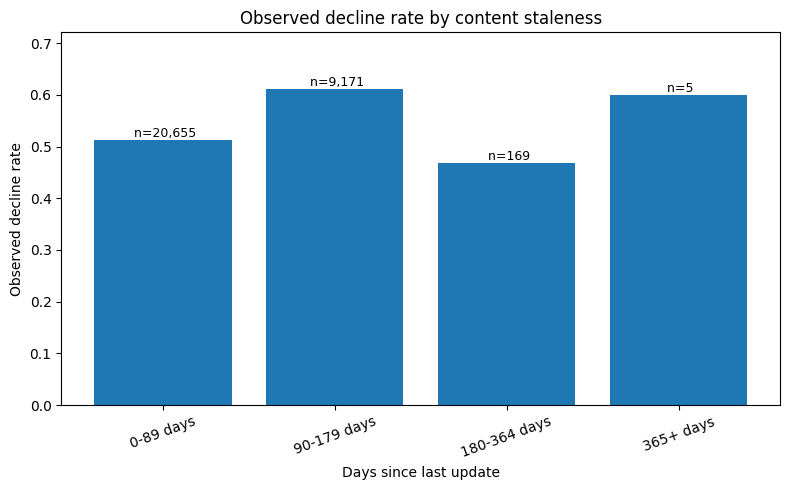

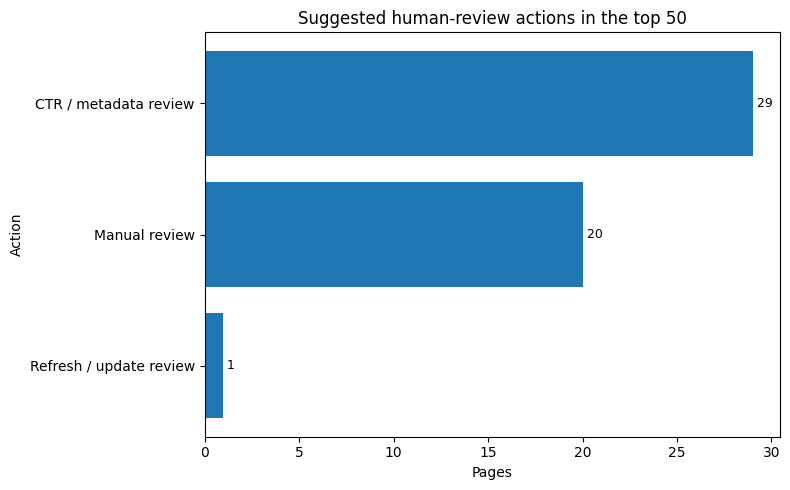

EXPORT MANIFEST


,path,purpose,paper_use
0,work/outputs/w07_ranked_action_queue.csv,Regenerated ranked action queue,Recommendations source; do not publish raw IDs
1,work/outputs/w07_playbook_metrics.json,Metrics / design receipt,Trace final paper numbers
2,work/figures/w07_decay_by_staleness.png,Aggregate decay/freshness figure,Reusable public-safe figure
3,work/figures/w07_top50_action_mix.png,Top-50 action mix figure,Reusable public-safe figure



GIT IGNORE CHECK
work/outputs/w07_ranked_action_queue.csv: IGNORED / regenerated
work/outputs/w07_playbook_metrics.json: TRACKABLE
work/figures/w07_decay_by_staleness.png: TRACKABLE
work/figures/w07_top50_action_mix.png: TRACKABLE

Do not force-add the ranked queue if git ignores it. Commit the executed notebook, the reusable aggregate figures, and the metrics receipt when they are trackable in your repo.


In [5]:
# ---------- Export queue, metrics receipt, and reusable figures ----------

import json
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("work/outputs")
FIGURE_DIR = Path("work/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

QUEUE_PATH = OUTPUT_DIR / "w07_ranked_action_queue.csv"
METRICS_PATH = OUTPUT_DIR / "w07_playbook_metrics.json"
DECAY_FIG_PATH = FIGURE_DIR / "w07_decay_by_staleness.png"
ACTION_FIG_PATH = FIGURE_DIR / "w07_top50_action_mix.png"

queue_export_columns = [
    "rank",
    "content_id",
    "client_id",
    "review_priority_score",
    "model_risk_score",
    "demand_percentile",
    "impressions_90d",
    "ctr",
    "avg_position",
    "days_since_last_update",
    "content_type",
    "position_band",
    "ctr_band_median",
    "ctr_gap_vs_band",
    "archetype",
    "suggested_action",
    "reason_codes",
    "value_tier",
    "estimated_effort",
    "cost_value_note",
    "requires_human_review",
]

available_export_columns = [
    c for c in queue_export_columns if c in queue.columns
]
queue[available_export_columns].to_csv(QUEUE_PATH, index=False)

# Figure 1: observed decline rate by staleness band.
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    decay_summary["staleness_band"].astype(str),
    decay_summary["observed_decline_rate"],
)
ax.set_title("Observed decline rate by content staleness")
ax.set_xlabel("Days since last update")
ax.set_ylabel("Observed decline rate")
ax.set_ylim(0, max(0.05, decay_summary["observed_decline_rate"].max() * 1.18))
ax.tick_params(axis="x", rotation=20)

for bar, n in zip(bars, decay_summary["pages"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f" n={int(n):,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

fig.tight_layout()
fig.savefig(DECAY_FIG_PATH, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

# Figure 2: action mix in the operational top 50.
action_mix_for_plot = (
    top50["suggested_action"]
    .value_counts()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    action_mix_for_plot.index,
    action_mix_for_plot.values,
)
ax.set_title("Suggested human-review actions in the top 50")
ax.set_xlabel("Pages")
ax.set_ylabel("Action")

for bar in bars:
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {int(bar.get_width())}",
        va="center",
        fontsize=9,
    )

fig.tight_layout()
fig.savefig(ACTION_FIG_PATH, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

decay_records = []
for row in decay_summary.itertuples(index=False):
    decay_records.append({
        "staleness_band": str(row.staleness_band),
        "pages": int(row.pages),
        "observed_decline_rate": float(row.observed_decline_rate),
        "median_impressions": float(row.median_impressions)
        if pd.notna(row.median_impressions) else None,
    })

top50_action_counts = {
    str(k): int(v)
    for k, v in top50["suggested_action"].value_counts().to_dict().items()
}

archetype_counts = {
    str(k): int(v)
    for k, v in top50["archetype"].value_counts().to_dict().items()
}

metrics_receipt = {
    "source": {
        "dataset": "data/raw/content_refresh_anonymized.csv",
        "starter_rows": int(len(df)),
        "queue_eligibility_min_impressions_90d": int(MIN_IMPRESSIONS),
        "eligible_queue_rows": int(len(queue)),
    },
    "week6_validation_receipt": {
        "split": "client-grouped holdout",
        "client_overlap": int(client_overlap),
        "precision_at_50": float(validated_p50),
        "test_decline_base_rate": float(validated_base_rate),
        "lift_at_50": float(validated_lift50),
        "roc_auc": float(validated_auc),
        "average_precision": float(validated_ap),
    },
    "week7_playbook": {
        "model": "Week-5/6 Logistic Regression refit on all starter rows for ranking only",
        "risk_weight": float(RISK_WEIGHT),
        "demand_weight": float(DEMAND_WEIGHT),
        "top_k": int(TOP_K),
        "risk_high_threshold_q75": float(risk_q75),
        "top50_action_counts": top50_action_counts,
        "top50_archetype_counts": archetype_counts,
        "all_rows_require_human_review": bool(queue["requires_human_review"].all()),
    },
    "decay_refresh_descriptive_check": {
        "claim_level": "observed association only; not causal",
        "staleness_bands": decay_records,
    },
    "monitoring_reference": {
        "p50_reaudit_floor": float(p50_reaudit_floor),
        "lift50_reaudit_floor": float(lift50_reaudit_floor),
        "numeric_feature_reference": feature_reference,
        "content_type_share": {
            str(k): float(v) for k, v in content_type_reference.items()
        },
    },
    "exports": {
        "queue_csv": str(QUEUE_PATH),
        "metrics_json": str(METRICS_PATH),
        "decay_figure": str(DECAY_FIG_PATH),
        "top50_action_figure": str(ACTION_FIG_PATH),
    },
}

with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics_receipt, f, indent=2)

export_manifest = pd.DataFrame([
    {
        "path": str(QUEUE_PATH),
        "purpose": "Regenerated ranked action queue",
        "paper_use": "Recommendations source; do not publish raw IDs",
    },
    {
        "path": str(METRICS_PATH),
        "purpose": "Metrics / design receipt",
        "paper_use": "Trace final paper numbers",
    },
    {
        "path": str(DECAY_FIG_PATH),
        "purpose": "Aggregate decay/freshness figure",
        "paper_use": "Reusable public-safe figure",
    },
    {
        "path": str(ACTION_FIG_PATH),
        "purpose": "Top-50 action mix figure",
        "paper_use": "Reusable public-safe figure",
    },
])

print("EXPORT MANIFEST")
display(export_manifest)

# Show what git will ignore in the current repo rather than guessing.
if Path(".git").exists():
    print("\nGIT IGNORE CHECK")
    for path in [QUEUE_PATH, METRICS_PATH, DECAY_FIG_PATH, ACTION_FIG_PATH]:
        result = subprocess.run(
            ["git", "check-ignore", "-q", str(path)],
            capture_output=True,
        )
        status = "IGNORED / regenerated" if result.returncode == 0 else "TRACKABLE"
        print(f"{path}: {status}")

print(
    "\nDo not force-add the ranked queue if git ignores it. "
    "Commit the executed notebook, the reusable aggregate figures, and the metrics receipt "
    "when they are trackable in your repo."
)


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under work/notebooks/ — then submit your repo URL on the card. Done.